In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ============================================================
# STEP 1: Combine all three cutters
# ============================================================
df_c1 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c1_aggregated_features.csv")
df_c4 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c4_aggregated_features.csv")
df_c6 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c6_aggregated_features.csv")

df_c1["cutter"] = "C1"
df_c4["cutter"] = "C4"
df_c6["cutter"] = "C6"

df_combined = pd.concat([df_c1, df_c4, df_c6], ignore_index=True)

y = df_combined[["flute_1", "flute_2", "flute_3"]]
X = df_combined.drop(
    columns=["cut_number", "flute_1", "flute_2", "flute_3", "max_wear", "cutter"]
)

print("X shape:", X.shape)  # (945, 378)
print("y shape:", y.shape)  # (945, 3)

# ============================================================
# STEP 2: Train/test split (no scaling needed — trees are scale-invariant)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# ============================================================
# STEP 3: Train Random Forest
# ============================================================
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1  # uses all CPU cores, trains faster
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

df_combined["pred_flute_1"] = y_pred[:, 0]
df_combined["pred_flute_2"] = y_pred[:, 1]
df_combined["pred_flute_3"] = y_pred[:, 2]
df_combined["pred_max_wear"] = y_pred.max(axis=1)  # max across the 3 predicted flutes


# ============================================================
# STEP 4: Evaluate per flute
# ============================================================
for i, flute in enumerate(["flute_1", "flute_2", "flute_3"]):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    mape = mean_absolute_percentage_error(y_test.iloc[:, i], y_pred[:, i]) * 100
    print(f"{flute} -> MSE: {mse:.4f}, MAPE: {mape:.2f}%")

# ============================================================
# STEP 5: Plot actual vs predicted
# ============================================================
def plot_predictions(y_actual, y_pred):
    y_actual = np.array(y_actual)
    y_pred = np.array(y_pred)
    n_targets = y_actual.shape[1]
    flute_labels = [f"Flute {i+1}" for i in range(n_targets)]

    fig, axes = plt.subplots(1, n_targets, figsize=(24, 7))
    for i in range(n_targets):
        ax = axes[i]
        actual = y_actual[:, i]
        pred = y_pred[:, i]
        order = np.argsort(actual)

        mse = mean_squared_error(actual, pred)
        mape = mean_absolute_percentage_error(actual, pred) * 100

        ax.plot(actual[order], label="Actual wear", linewidth=3, color="tab:blue")
        ax.plot(pred[order], label="Predicted wear", marker="x",
                 markersize=4, linewidth=1, color="tab:orange")
        ax.set_title(flute_labels[i])
        ax.set_xlabel("Test sample (sorted by actual wear)")
        ax.set_ylabel("Wear Measurement")
        ax.legend(loc="upper left")
        ax.text(0.5, 0.85, f"MSE: {mse:.4f}\nMAPE: {mape:.2f}%",
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred)

# ============================================================
# STEP 6: Feature importance (Random Forest's built-in equivalent
# to Lasso's coefficients — shows which sensor features matter most)
# ============================================================
importances = rf.feature_importances_
sorted_idx = np.argsort(-importances)[:15]  # top 15 features
top_features = X.columns[sorted_idx]
top_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features — Random Forest")
plt.tight_layout()
plt.show()

X shape: (945, 378)
y shape: (945, 3)


ValueError: Length of values (189) does not match length of index (945)

Combined shape: (945, 384)
X shape: (945, 378)
y shape: (945, 3)
flute_1 -> MSE: 6.8496, MAPE: 1.69%
flute_2 -> MSE: 8.9161, MAPE: 1.61%
flute_3 -> MSE: 6.0907, MAPE: 1.45%
  cutter  cut_number   max_wear  pred_max_wear
0     C1           1  48.892617      41.990180
1     C1           2  49.570815      44.370558
2     C1           3  50.302867      47.964324
3     C1           4  51.083652      57.046059
4     C1           5  52.250329      53.015193


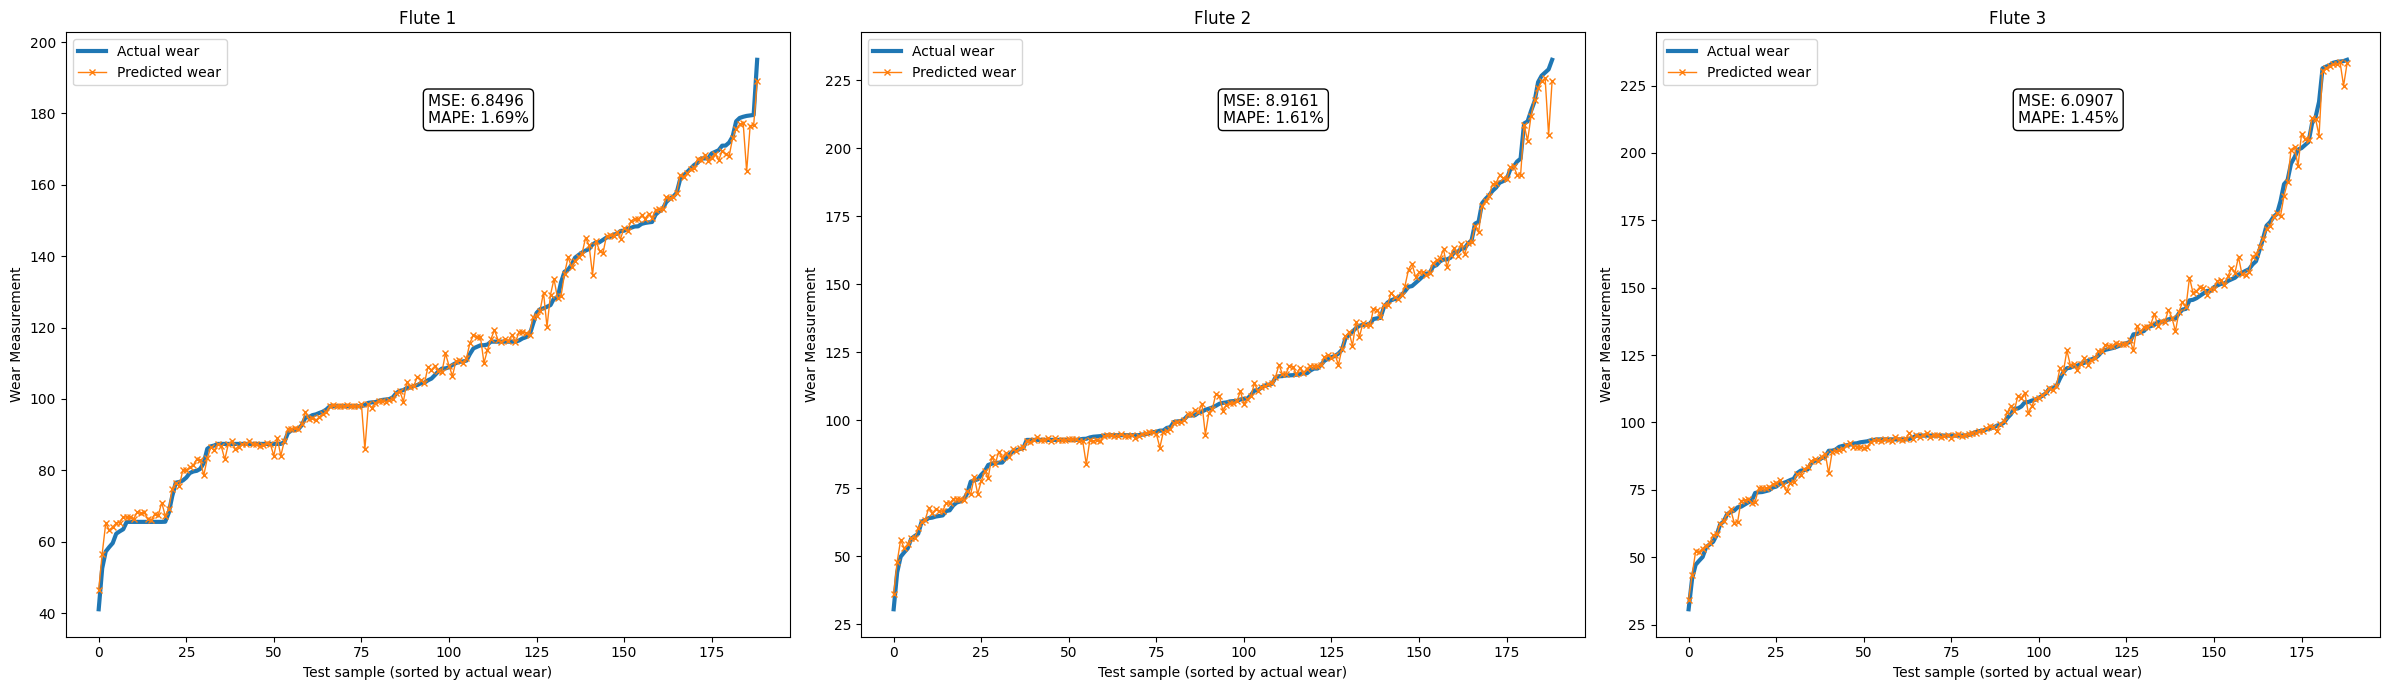

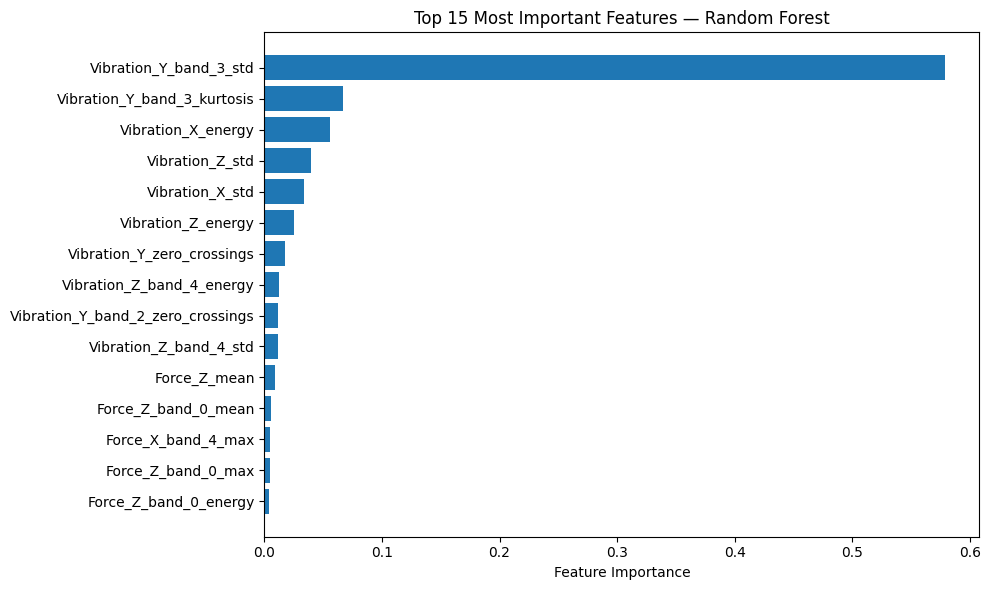

Saved: combined_with_predictions.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ============================================================
# STEP 1: Combine all three cutters
df_c1 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c1_aggregated_features.csv")
df_c4 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c4_aggregated_features.csv")
df_c6 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c6_aggregated_features.csv")

df_c1["cutter"] = "C1"
df_c4["cutter"] = "C4"
df_c6["cutter"] = "C6"

df_combined = pd.concat([df_c1, df_c4, df_c6], ignore_index=True)
print("Combined shape:", df_combined.shape)  # (945, 384)

# ============================================================
# STEP 2: Define X and y
# ============================================================
y = df_combined[["flute_1", "flute_2", "flute_3"]]
X = df_combined.drop(
    columns=["cut_number", "flute_1", "flute_2", "flute_3", "max_wear", "cutter"]
)

print("X shape:", X.shape)  # (945, 378)
print("y shape:", y.shape)  # (945, 3)

# ============================================================
# STEP 3: Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# ============================================================
# STEP 4: Train Random Forest
# ============================================================
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ============================================================
# STEP 5: Evaluate on TEST set only (honest accuracy check)
# ============================================================
y_pred_test = rf.predict(X_test)   # shape (189, 3) — test rows only

for i, flute in enumerate(["flute_1", "flute_2", "flute_3"]):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_test[:, i])
    mape = mean_absolute_percentage_error(y_test.iloc[:, i], y_pred_test[:, i]) * 100
    print(f"{flute} -> MSE: {mse:.4f}, MAPE: {mape:.2f}%")

# ============================================================
# STEP 6: Predict on the FULL dataset (all 945 rows) to add
# predicted max_wear into df_combined — this is what fixes the error
# ============================================================
y_pred_all = rf.predict(X)   # shape (945, 3) — matches df_combined's length

df_combined["pred_flute_1"] = y_pred_all[:, 0]
df_combined["pred_flute_2"] = y_pred_all[:, 1]
df_combined["pred_flute_3"] = y_pred_all[:, 2]
df_combined["pred_max_wear"] = y_pred_all.max(axis=1)   # 945 values, matches df_combined length

print(df_combined[["cutter", "cut_number", "max_wear", "pred_max_wear"]].head())

# ============================================================
# STEP 7: Plot actual vs predicted (on test set, for honest visual check)
# ============================================================
def plot_predictions(y_actual, y_pred):
    y_actual = np.array(y_actual)
    y_pred = np.array(y_pred)
    n_targets = y_actual.shape[1]
    flute_labels = [f"Flute {i+1}" for i in range(n_targets)]

    fig, axes = plt.subplots(1, n_targets, figsize=(24, 7))
    for i in range(n_targets):
        ax = axes[i]
        actual = y_actual[:, i]
        pred = y_pred[:, i]
        order = np.argsort(actual)

        mse = mean_squared_error(actual, pred)
        mape = mean_absolute_percentage_error(actual, pred) * 100

        ax.plot(actual[order], label="Actual wear", linewidth=3, color="tab:blue")
        ax.plot(pred[order], label="Predicted wear", marker="x",
                 markersize=4, linewidth=1, color="tab:orange")
        ax.set_title(flute_labels[i])
        ax.set_xlabel("Test sample (sorted by actual wear)")
        ax.set_ylabel("Wear Measurement")
        ax.legend(loc="upper left")
        ax.text(0.5, 0.85, f"MSE: {mse:.4f}\nMAPE: {mape:.2f}%",
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred_test)

# ============================================================
# STEP 8: Feature importance
# ============================================================
importances = rf.feature_importances_
sorted_idx = np.argsort(-importances)[:15]
top_features = X.columns[sorted_idx]
top_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features — Random Forest")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: Save final dataset with predictions
# ============================================================
df_combined.to_csv("combined_with_predictions.csv", index=False)
print("Saved: combined_with_predictions.csv")

In [8]:
df_combined.head(15)

,cut_number,Force_X_min,Force_X_max,Force_X_mean,Force_X_std,Force_X_skew,Force_X_kurtosis,Force_X_energy,Force_X_entropy,Force_X_zero_crossings,...,AE_RMS_band_4_zero_crossings,flute_1,flute_2,flute_3,max_wear,cutter,pred_flute_1,pred_flute_2,pred_flute_3,pred_max_wear
0,1,-2.501,3.744,0.400857,0.842471,0.115205,-0.245189,1.108930e+05,11.470662,3086,...,2484,32.317114,48.892617,37.720825,48.892617,C1,41.990180,39.376009,33.813832,41.990180
1,2,-4.219,8.427,1.028151,1.864981,0.606325,0.022639,9.854836e+05,11.912434,7897,...,4362,37.914879,49.570815,37.720825,49.570815,C1,40.811752,44.370558,36.073189,44.370558
2,3,-5.994,11.534,1.776092,2.672095,0.605046,0.073317,2.248208e+06,11.936781,7446,...,4486,43.087910,50.302867,37.720825,50.302867,C1,43.027783,47.964324,37.621813,47.964324
3,4,-6.157,11.788,2.104920,2.992561,0.586804,0.102548,2.928016e+06,11.947876,7116,...,4520,47.859072,51.083652,37.849851,51.083652,C1,56.086494,57.046059,47.040474,57.046059
4,5,-4.288,12.555,2.831384,2.979764,0.612714,0.016936,3.708553e+06,11.984019,6409,...,4523,52.250329,51.908288,38.172665,52.250329,C1,53.015193,49.716405,39.400903,53.015193
5,6,-4.167,14.291,2.930668,2.987073,0.590819,-0.050647,3.832295e+06,11.987076,6232,...,4496,56.282766,52.772127,38.617556,56.282766,C1,55.454438,50.702463,39.474161,55.454438
6,7,-4.910,13.014,3.016910,3.015806,0.574441,0.006708,3.985570e+06,11.994900,5888,...,4522,59.976616,53.670745,39.174556,59.976616,C1,59.647451,52.405329,40.478930,59.647451
7,8,-4.147,13.322,3.094589,2.976188,0.558254,-0.053230,4.036375e+06,12.002798,5611,...,4517,63.351288,54.599939,39.834155,63.351288,C1,64.560268,54.521410,42.134480,64.560268
8,9,-5.616,10.615,2.710924,2.873495,0.164795,-0.572489,3.429413e+06,12.012010,5373,...,4508,66.425391,55.555716,40.587292,66.425391,C1,67.921013,56.134880,42.720849,67.921013
9,10,-6.076,10.990,2.689305,2.861803,0.151674,-0.515025,3.376360e+06,12.011186,5130,...,4485,69.216757,56.534286,41.425337,69.216757,C1,68.120129,55.930452,42.633303,68.120129
